### Comportamiento de la Demanda de Energía Eléctrica en el MEM ###
Información Estadística Histórica Enero 2017 a Abril 2026

Acompañando a la información y análisis de los datos operativos de corto plazo en relación al comportamiento de la demanda, se pone a disposición distintas bases de los datos DEMANDA NETA DIARIA a nivel de Total País, por Región, y detallando la demanda de los Grandes Usuarios del MEM (GUMA), agrupados en Ramas y Actividades características. 

En detalle cada hoja contiene:
- Hoja Base Datos Región => Seguimiento de la demanda neta diaria por región eléctrica
- Hoja Base Datos Tipo Usuario => Seguimiento de la demanda neta diaria de los Distribuidores y Grandes Usuarios del MEM, dividiendo entre por rama y región.
- Hoja Datos GUMAs Actividad => Seguimiento de la demanda neta diaria de los Grandes Usuarios del MEM, dividiendo por rama y actividad.


A diferencia de la información operativa, la demanda es NETA en estas bases de datos, los resultados se encuentran consolidados de acuerdo a las mediciones que se obtienen del sistema de medición comercial (SMEC) y utilizados para realizar la transacción económica de cada agente demandante.

**En este trabajo el análisis se enfoca en la serie de demanda de energía eléctrica diaria de la la región de Gran Buenos Aires.**



In [2]:
from pathlib import Path

import pandas as pd

archivo = Path("data") / "Base_Demanda_Diaria_2017_2026.xlsx"
hoja = "Datos_Region"

df_data_region = pd.read_excel(archivo, sheet_name=hoja)
df_data_region.head(10)

,DEMANDA NETA POR REGIÓN,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,UNIDAD MW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BASE TRANSACCIÓNES ECONÓMICAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
4,2017,2017-01-01 00:00:00,2017-01-01 00:00:00,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
5,2017,2017-01-01 00:00:00,2017-01-02 00:00:00,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
6,2017,2017-01-01 00:00:00,2017-01-03 00:00:00,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
7,2017,2017-01-01 00:00:00,2017-01-04 00:00:00,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
8,2017,2017-01-01 00:00:00,2017-01-05 00:00:00,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9
9,2017,2017-01-01 00:00:00,2017-01-06 00:00:00,Viernes habiles,5781.113583,1801.103708,1367.353708,1929.803917,1135.512667,1354.617292,1218.666875,615.4865,550.862542,15754.520792,24.3


In [3]:
columnas = df_data_region.iloc[3]
columnas_validas = columnas.notna()

# Se toman los encabezados desde la fila 3 del DataFrame original.
df_data_region = df_data_region.loc[4:, columnas_validas].copy()
df_data_region.columns = columnas[columnas_validas]
df_data_region = df_data_region.reset_index(drop=True)

# Se normalizan mes y fecha para conservar solo sus componentes numéricos.
df_data_region["MES"] = pd.to_datetime(df_data_region["MES"], errors="coerce").dt.month.astype("Int64")
df_data_region["Fecha"] = pd.to_datetime(df_data_region["Fecha"], errors="coerce").dt.day.astype("Int64")
df_data_region["AÑO"] = pd.to_numeric(df_data_region["AÑO"], errors="coerce").astype("Int64")

df_data_region.head()


3,AÑO,MES,Fecha,Tipo día,GRAN BS.AS.,BUENOS AIRES,CENTRO,LITORAL,CUYO,NOROESTE,NORESTE,COMAHUE,PATAGONICA,DEMANDA TOTAL,TEMPERATURA REFERENCIA MEDIA GBA °C
0,2017,1,1,Domingo o Feriado,6352.695208,1472.2705,1134.39425,1766.623958,903.135875,1602.126625,1400.333417,561.243208,500.863042,15693.686083,31.3
1,2017,1,2,Lunes habiles,6617.86375,1779.435208,1363.527292,1963.925833,1091.811167,1627.56725,1585.616708,638.835167,540.57775,17209.160125,25.35
2,2017,1,3,Martes Habiles,6677.996167,1888.984333,1600.744625,2036.345917,1178.718583,1806.474,1652.989833,624.649083,536.472333,18003.374875,25.45
3,2017,1,4,Miercoles habiles,6426.997625,1840.623833,1356.381292,1756.6405,1078.90325,1759.855667,1604.750375,598.4005,528.904083,16951.457125,27
4,2017,1,5,Jueves Habiles,5873.95075,1770.942583,1366.018917,1848.409375,1037.791833,1403.490042,1228.303125,585.206708,524.657125,15638.770458,21.9


In [7]:
partes_fecha = df_data_region[["AÑO", "MES", "Fecha"]].astype("Int64")
fecha = pd.to_datetime(
    {
        "year": partes_fecha["AÑO"],
        "month": partes_fecha["MES"],
        "day": partes_fecha["Fecha"],
    },
    errors="coerce",
)

# Se construye una fecha real a partir de año, mes y día.
demanda_gbsas = pd.DataFrame(
    {
        "fecha": fecha,
        "demanda": pd.to_numeric(df_data_region["GRAN BS.AS."], errors="coerce"),
        "temp_media": pd.to_numeric(
            df_data_region["TEMPERATURA REFERENCIA MEDIA GBA °C"], errors="coerce"
        ),
    }
)

demanda_gbsas.head()


,fecha,demanda,temp_media
0,2017-01-01,6352.695208,31.30
1,2017-01-02,6617.863750,25.35
2,2017-01-03,6677.996167,25.45
3,2017-01-04,6426.997625,27.00
4,2017-01-05,5873.950750,21.90


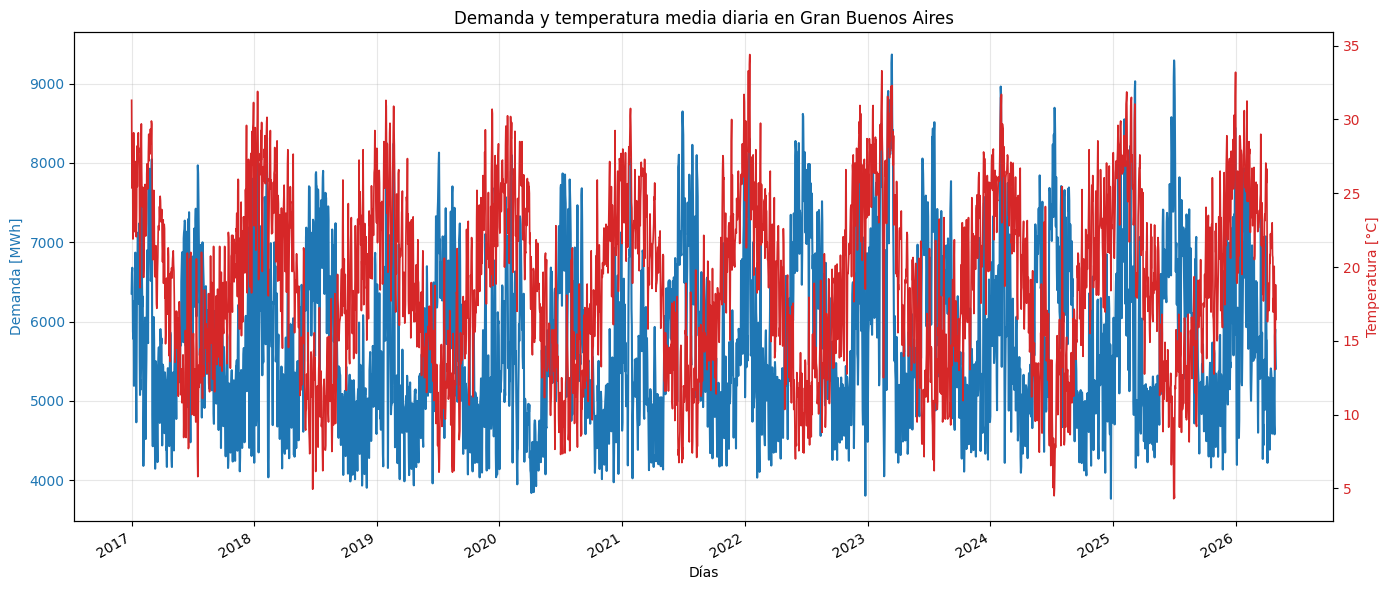

In [9]:
import matplotlib.pyplot as plt

# Se ordenan los datos para asegurar la secuencia temporal.
datos_grafico = demanda_gbsas.sort_values("fecha").dropna(subset=["fecha"])

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico["fecha"], datos_grafico["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico["fecha"], datos_grafico["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


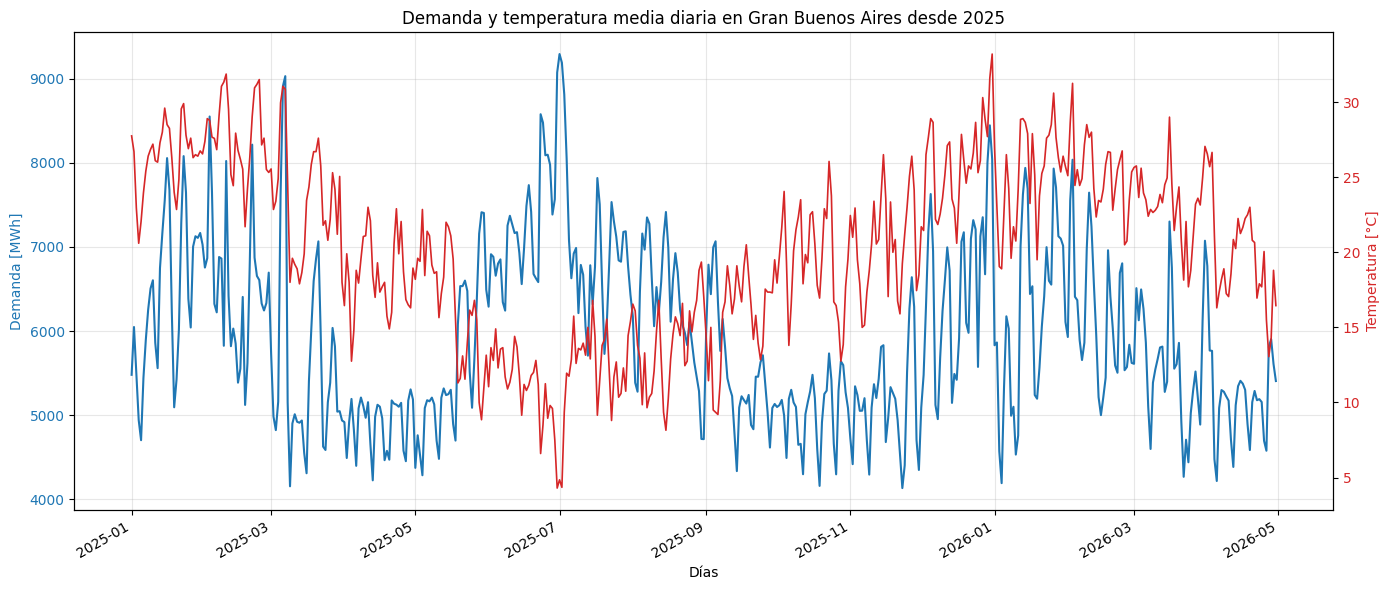

In [10]:
# Se filtran los datos desde enero de 2025 en adelante.
datos_grafico_2025 = demanda_gbsas.loc[
    demanda_gbsas["fecha"] >= pd.Timestamp("2025-01-01")
].sort_values("fecha")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(datos_grafico_2025["fecha"], datos_grafico_2025["demanda"], color="tab:blue", linewidth=1.5)
ax2.plot(datos_grafico_2025["fecha"], datos_grafico_2025["temp_media"], color="tab:red", linewidth=1.2)

# Se asignan etiquetas y unidades a cada eje vertical.
ax1.set_xlabel("Días")
ax1.set_ylabel("Demanda [MWh]", color="tab:blue")
ax2.set_ylabel("Temperatura [°C]", color="tab:red")
ax1.set_title("Demanda y temperatura media diaria en Gran Buenos Aires desde 2025")

ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()
